# 1.Installation Packages and Libraries

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)
from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LinearRegression,
    RidgeCV,
    LassoCV,
    ElasticNetCV
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    root_mean_squared_error,
    r2_score
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.model_selection import GridSearchCV

from ucimlrepo import fetch_ucirepo

#2. Forest Data Creation using ucimlrepo

In [22]:
df = pd.read_pickle("processed_forest_fires.pkl")

In [23]:
df.head()

,x,y,month,day,ffmc,dmc,dc,isi,temp,rh,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


In [24]:
df = df.drop(columns = ["month", "day", "x", "y"])
target = "temp"
X = df.drop(columns = [target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

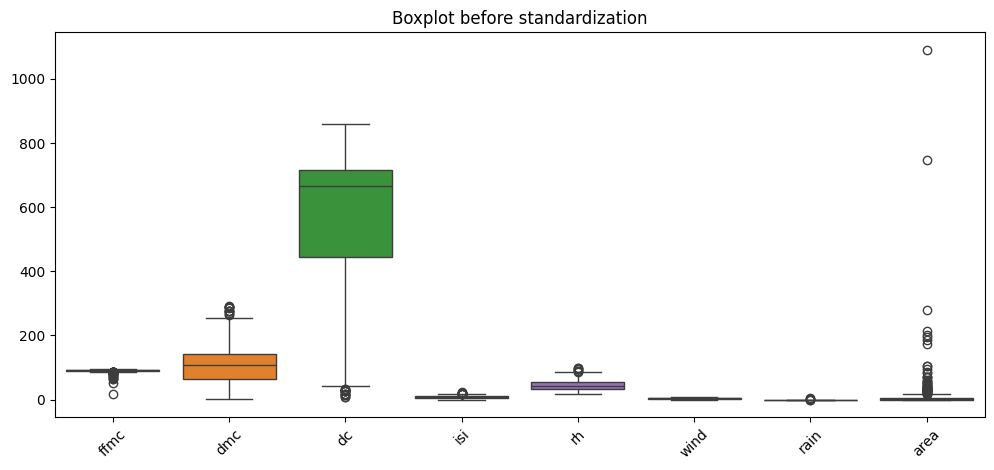

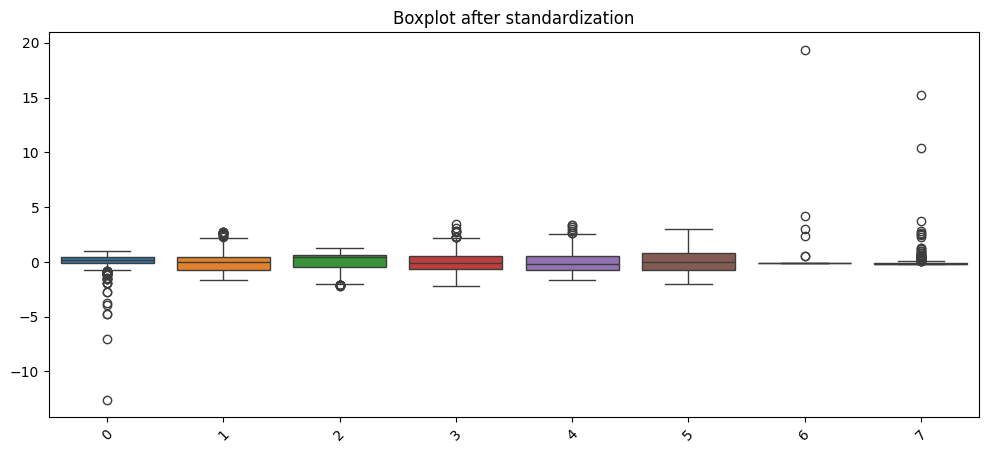

In [25]:
plt.figure(figsize=(12,5))
sns.boxplot(data=X_train)
plt.title("Boxplot before standardization")
plt.xticks(rotation=45)
plt.show()
print()

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_train_scaled = scaler.fit_transform(X_train)

plt.figure(figsize=(12,5))
sns.boxplot(data=X_train_scaled)
plt.title("Boxplot after standardization")
plt.xticks(rotation=45)
plt.show()

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 513 entries, 0 to 516
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ffmc    513 non-null    float64
 1   dmc     513 non-null    float64
 2   dc      513 non-null    float64
 3   isi     513 non-null    float64
 4   temp    513 non-null    float64
 5   rh      513 non-null    int64  
 6   wind    513 non-null    float64
 7   rain    513 non-null    float64
 8   area    513 non-null    float64
dtypes: float64(8), int64(1)
memory usage: 40.1 KB


In [27]:
num_features = X.select_dtypes(include = ["float64", "int64"]).columns
print(f"NUmerical features: {list(num_features)}")

NUmerical features: ['ffmc', 'dmc', 'dc', 'isi', 'rh', 'wind', 'rain', 'area']


In [28]:
num_transformer = StandardScaler()
cat_transformer = OneHotEncoder(handle_unknown="ignore")

preprocessor = ColumnTransformer(
    transformers = [
        ("num", num_transformer, num_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('num', StandardScaler(),
                                 Index(['ffmc', 'dmc', 'dc', 'isi', 'rh', 'wind', 'rain', 'area'], dtype='object'))])

In [29]:
models = {
    "Linear": LinearRegression(),
    "LassoCV": LassoCV( cv = 5),
    "RidgeCV": RidgeCV(alphas=[0.01,0.1,1,10,100]),
    "ElasticNetCV": ElasticNetCV(cv = 5),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(kernel="rbf"),
    "KNN": KNeighborsRegressor(n_neighbors=5)
}

In [30]:
results = []
trained_models = {}

for name, model in models.items():

  pipe = Pipeline([
      ("prep", preprocessor),
      ("model", model)
  ])

  pipe.fit(X_train, y_train)
  y_pred = pipe.predict(X_test)

  results.append({
      "Model": name,
      "MAE": mean_absolute_error(y_test, y_pred),
      "MSE": mean_squared_error(y_test, y_pred),
      "RMSE": root_mean_squared_error(y_test, y_pred),
      "R^2": r2_score(y_test, y_pred)
  })
  trained_models[name] = pipe

results_df = pd.DataFrame(results).sort_values("R^2", ascending = False)

best_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_name]
print(best_name)

results_df

Gradient Boosting


,Model,MAE,MSE,RMSE,R^2
5,Gradient Boosting,1.954291,6.546806,2.558673,0.787081
4,Random Forest,1.967271,6.816791,2.610899,0.778301
7,KNN,2.465049,9.866256,3.141060,0.679124
6,SVR,2.653045,12.599523,3.549581,0.590231
2,RidgeCV,3.132934,16.519193,4.064381,0.462754
3,ElasticNetCV,3.150103,16.914491,4.112723,0.449898
1,LassoCV,3.148695,16.983543,4.121109,0.447652
0,Linear,3.176684,17.533438,4.187295,0.429768


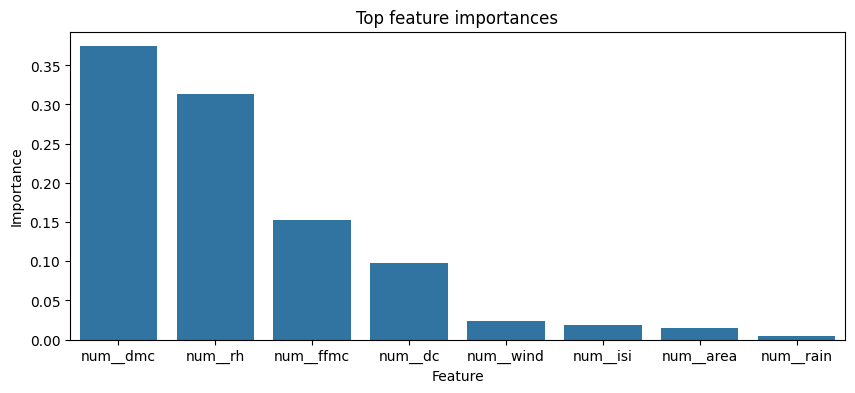

In [31]:
model = best_model.named_steps["model"]

feature_names = best_model.named_steps["prep"].get_feature_names_out()

feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize = (10, 4))
sns.barplot(data = feat_imp, x = "Feature", y = "Importance")
plt.title("Top feature importances")
plt.show()

In [32]:
top3_models = {
    "Gradient Boosting": {
        "pipe": Pipeline([("prep", preprocessor), ("model", GradientBoostingRegressor(random_state=42))]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__learning_rate": [0.01, 0.05, 0.1],
            "model__max_depth": [2, 3, 4, 5],
            "model__min_samples_split": [2, 5, 10]
        }
    },
    "Random Forest": {
        "pipe": Pipeline([("prep", preprocessor), ("model", RandomForestRegressor(random_state=42))]),
        "params": {
            "model__n_estimators": [100, 200, 300],
            "model__max_depth": [None, 5, 10, 15],
            "model__min_samples_split": [2, 5, 10]
        }
    },
    "KNN": {
        "pipe": Pipeline([("prep", preprocessor), ("model", KNeighborsRegressor())]),
        "params": {
            "model__n_neighbors": [3, 5, 7, 9, 11],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2],
            "model__algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
        }
    }
}

In [33]:
tuned_grids = {}

for name, info in top3_models.items():
    grid = GridSearchCV(
        info["pipe"],
        info["params"],
        cv=5,
        scoring="r2",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)

    tuned_grids[name] = grid

In [34]:
for name, grid in tuned_grids.items():
    y_pred = grid.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    print(f"Model: {name}")
    print("Best Parameters:", grid.best_params_)
    print(f"R² on test: {r2:.4f}")
    print()

Model: Gradient Boosting
Best Parameters: {'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__min_samples_split': 2, 'model__n_estimators': 300}
R² on test: 0.7985

Model: Random Forest
Best Parameters: {'model__max_depth': 15, 'model__min_samples_split': 2, 'model__n_estimators': 300}
R² on test: 0.7818

Model: KNN
Best Parameters: {'model__algorithm': 'auto', 'model__n_neighbors': 5, 'model__p': 1, 'model__weights': 'distance'}
R² on test: 0.6989



In [35]:
best_name = max(tuned_grids, key=lambda n: r2_score(y_test, tuned_grids[n].predict(X_test)))
best_grid = tuned_grids[best_name]
best_model = best_grid.best_estimator_
best_model

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['ffmc', 'dmc', 'dc', 'isi', 'rh', 'wind', 'rain', 'area'], dtype='object'))])),
                ('model',
                 GradientBoostingRegressor(max_depth=4, n_estimators=300,
                                           random_state=42))])

In [39]:
import pickle

to_save = {
    "model_pipeline": best_model,
    "scaler": best_model.named_steps["prep"].named_transformers_["num"],
    "params": best_grid.best_params_
}

with open("../best_model_full.pkl", "wb") as f:
    pickle.dump(to_save, f)